In [5]:
import torchvision
import torch
import torchvision.transforms as transforms
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
from tqdm import tqdm

In [6]:
#Kindly keep the dataset in the google drive and allow the permission to access it.
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
def show_img(folder_path, class_name):
    files = [f for f in os.listdir(folder_path)]

    # pick 4 random images
    selected_files = random.sample(files, 6)

    plt.figure(figsize=(8,2))

    for i, file_name in enumerate(selected_files):
        file_path = os.path.join(folder_path, file_name)

        image = np.load(file_path).squeeze()

        plt.subplot(1, 6, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(file_name, fontsize=8)
        plt.axis('off')

    plt.suptitle(f"Class: {class_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [8]:
# Copy Dataset to Local SSD
import shutil

if os.path.exists('/content/dataset'):
    print("Dataset already exists on local SSD, skipping copy.")
else:
    print("Copying dataset to local SSD...")
    shutil.copytree(
        '/content/drive/MyDrive/Colab Notebooks/dataset',
        '/content/dataset'
    )
    print("Done!")

train_dir = '/content/dataset/train'
val_dir   = '/content/dataset/val'

Copying dataset to local SSD...
Done!


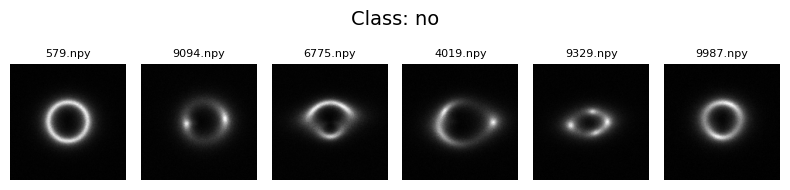

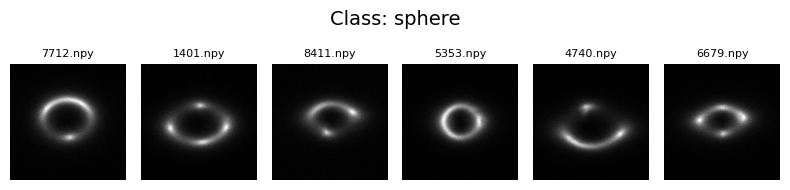

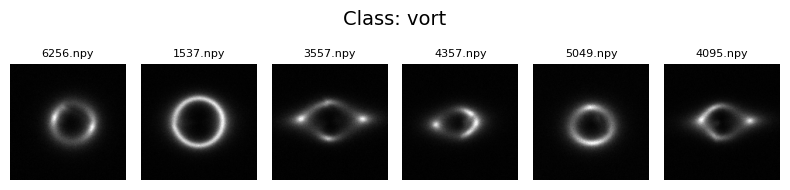

In [9]:
train_dir = '/content/dataset/train'
val_dir   = '/content/dataset/val'

random.seed(42) #For reproduciblity
for class_name in ['no', 'sphere', 'vort']:
    show_img(os.path.join(train_dir, class_name), class_name)

In [10]:
# transformations
from torchvision.transforms import transforms

dataset_mean = [0.485, 0.456, 0.406]
dataset_std  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.ToTensor(),
    #converting to 3 channels
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean = dataset_mean, std = dataset_std)
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean = dataset_mean, std = dataset_std)
])

In [11]:
# Dataset class

class LensingDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        class_map = {'no': 0, 'sphere': 1, 'vort': 2}

        for class_name, label in class_map.items():
            class_path = os.path.join(root_dir, class_name)
            for fname in sorted(os.listdir(class_path)):
                self.data.append(os.path.join(class_path, fname))
                self.labels.append(label)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
      img = np.load(self.data[idx])
      img = img.squeeze(0)
      img = (img * 255).astype(np.uint8)
      img = np.ascontiguousarray(img)
      img = Image.fromarray(img).convert('L')

      if self.transform:
          img = self.transform(img)

      return img, self.labels[idx]

# DataLoaders
train_dataset = LensingDataset(train_dir, transform=train_transform)
val_dataset   = LensingDataset(val_dir,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

Train: 30044 images | Val: 7514 images


In [12]:
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_CLASSES = 3
NUM_EPOCHS  = 30
LR          = 1e-5
BATCH_SIZE  = 64
CLASS_NAMES = ['no', 'sphere', 'vort']

print(f"Training on: {DEVICE}")

Training on: cuda


In [16]:
import torch.nn as nn
from torchvision import models
import torch.optim as optim
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns
# Model
def build_resnet50(num_classes=3):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.5),
        nn.Linear(256, num_classes)
    )
    return model

model     = build_resnet50().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

print(model.fc)

Sequential(
  (0): Linear(in_features=2048, out_features=256, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=256, out_features=3, bias=True)
)


In [17]:
history      = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):

    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss /= total
    train_acc   = correct / total

    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{NUM_EPOCHS} [Val]  "):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)

            val_loss += loss.item() * imgs.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)

    val_loss /= total
    val_acc   = correct / total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  |  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pt")
        print(f"  ✓ Best model saved  →  Val Acc: {best_val_acc:.4f}")

    print("-" * 70)

Epoch 01/30 [Val]  : 100%|██████████| 118/118 [00:29<00:00,  3.96it/s]


Epoch 01/30  |  Train Loss: 1.0736  Train Acc: 0.3884  |  Val Loss: 1.0860  Val Acc: 0.3758
  ✓ Best model saved  →  Val Acc: 0.3758
----------------------------------------------------------------------


Epoch 02/30 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.07it/s]


Epoch 02/30  |  Train Loss: 0.8579  Train Acc: 0.5848  |  Val Loss: 0.8123  Val Acc: 0.6199
  ✓ Best model saved  →  Val Acc: 0.6199
----------------------------------------------------------------------


Epoch 03/30 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.17it/s]


...

Epoch 28/30  |  Train Loss: 0.1530  Train Acc: 0.9467  |  Val Loss: 0.1530  Val Acc: 0.9493
  ✓ Best model saved  →  Val Acc: 0.9493
----------------------------------------------------------------------


Epoch 29/30 [Val]  : 100%|██████████| 118/118 [00:27<00:00,  4.22it/s]


Epoch 29/30  |  Train Loss: 0.1483  Train Acc: 0.9487  |  Val Loss: 0.1551  Val Acc: 0.9478
----------------------------------------------------------------------


Epoch 30/30 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.11it/s]

Epoch 30/30  |  Train Loss: 0.1470  Train Acc: 0.9481  |  Val Loss: 0.1583  Val Acc: 0.9442
----------------------------------------------------------------------


In [18]:
# the model is still learning hence more epochs are added.
NUM_EXTRA = 10
START     = len(history['train_loss']) + 1

for epoch in range(START, START + NUM_EXTRA):

    model.train()
    train_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{START + NUM_EXTRA - 1} [Train]"):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    train_loss /= total
    train_acc   = correct / total

    model.eval()
    val_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{START + NUM_EXTRA - 1} [Val]  "):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs  = model(imgs)
            loss     = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct  += (outputs.argmax(1) == labels).sum().item()
            total    += labels.size(0)

    val_loss /= total
    val_acc   = correct / total

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch:02d}/{START + NUM_EXTRA - 1}  |  Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50.pt")
        print(f"  ✓ Best model saved  →  Val Acc: {best_val_acc:.4f}")
    print("-" * 70)

Epoch 31/40 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.19it/s]


Epoch 31/40  |  Train Loss: 0.1420  Train Acc: 0.9493  |  Val Loss: 0.1607  Val Acc: 0.9442
----------------------------------------------------------------------


Epoch 32/40 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.11it/s]


Epoch 32/40  |  Train Loss: 0.1394  Train Acc: 0.9505  |  Val Loss: 0.1476  Val Acc: 0.9486
----------------------------------------------------------------------


Epoch 33/40 [Val]  : 100%|██████████| 118/118 [00:29<00:00,  4.04it/s]


...

Epoch 38/40  |  Train Loss: 0.1270  Train Acc: 0.9558  |  Val Loss: 0.1639  Val Acc: 0.9441
----------------------------------------------------------------------


Epoch 39/40 [Val]  : 100%|██████████| 118/118 [00:28<00:00,  4.10it/s]


Epoch 39/40  |  Train Loss: 0.1229  Train Acc: 0.9574  |  Val Loss: 0.1492  Val Acc: 0.9485
----------------------------------------------------------------------


Epoch 40/40 [Val]  : 100%|██████████| 118/118 [00:29<00:00,  4.06it/s]


Epoch 40/40  |  Train Loss: 0.1210  Train Acc: 0.9572  |  Val Loss: 0.1401  Val Acc: 0.9532
  ✓ Best model saved  →  Val Acc: 0.9532
----------------------------------------------------------------------


Saved.


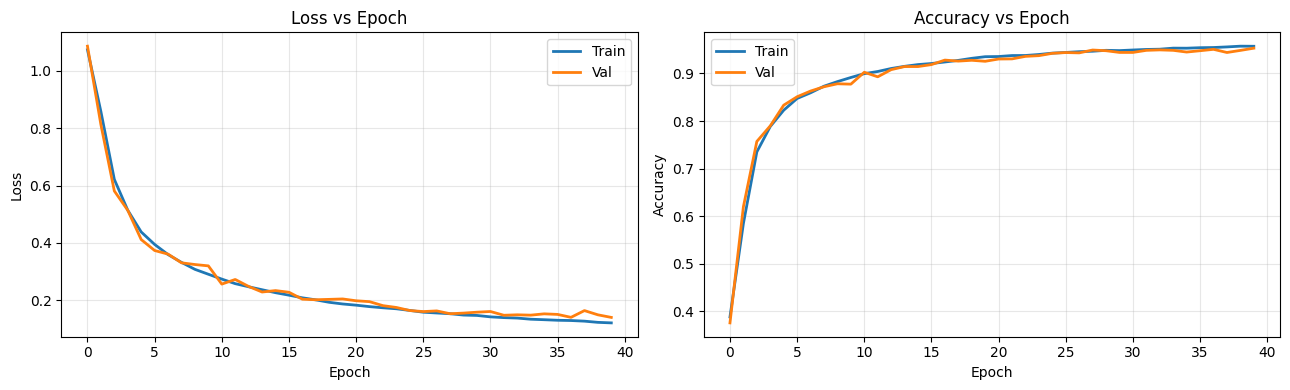

In [19]:
shutil.copy("best_resnet50.pt", "/content/drive/MyDrive/Colab Notebooks/best_resnet50.pt")
print("Saved.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Loss vs Epoch'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', linewidth=2)
axes[1].plot(history['val_acc'],   label='Val',   linewidth=2)
axes[1].set_title('Accuracy vs Epoch'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [20]:
model.load_state_dict(torch.load("best_resnet50.pt", map_location=DEVICE))
model.eval()

all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in tqdm(val_loader, desc="Evaluating"):
        outputs = model(imgs.to(DEVICE))
        probs   = torch.softmax(outputs, dim=1).cpu().numpy()
        all_labels.extend(labels.numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_probs.extend(probs)

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print(f"\nOverall Accuracy: {(all_preds == all_labels).mean():.4f}\n")
for i, name in enumerate(CLASS_NAMES):
    mask = all_labels == i
    print(f"  {name:>8s}  Accuracy: {(all_preds[mask] == all_labels[mask]).mean():.4f}")

Evaluating: 100%|██████████| 118/118 [00:28<00:00,  4.12it/s]


Overall Accuracy: 0.9532

        no  Accuracy: 0.9980
    sphere  Accuracy: 0.9040
      vort  Accuracy: 0.9574


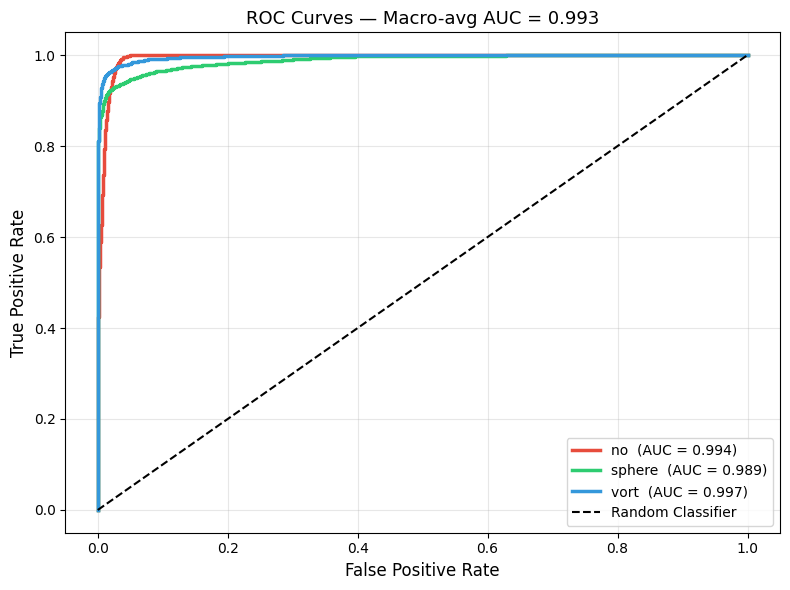

Macro-averaged AUC: 0.9930


In [21]:
colors    = ['#e74c3c', '#2ecc71', '#3498db']
fig, ax   = plt.subplots(figsize=(8, 6))
macro_auc = 0.0

for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    macro_auc  += roc_auc
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"{name}  (AUC = {roc_auc:.3f})")

macro_auc /= NUM_CLASSES
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title(f'ROC Curves — Macro-avg AUC = {macro_auc:.3f}', fontsize=13)
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("roc_curves.png", dpi=150)
plt.show()
print(f"Macro-averaged AUC: {macro_auc:.4f}")

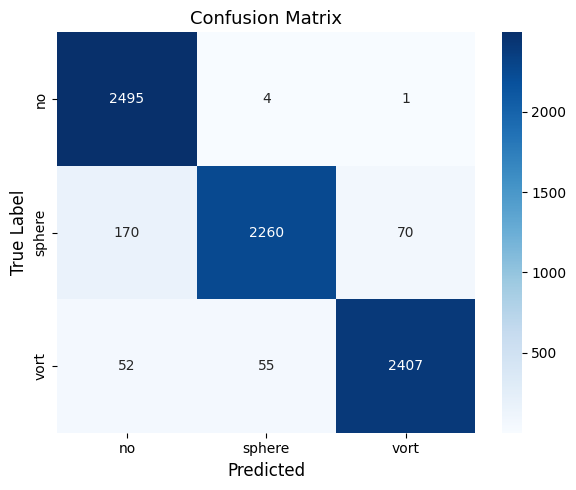

In [22]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()